## Calculate the standard deviation for the connectivity matrix (from farm to farm) ##
30 connectivity matrices in total were generated using randomly sampled trajectories 
The standard deviation was calculated using 10, 20 and 30 sampled matrices.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import csv
import json
import geopandas as gpd
import numpy as np

#### Combine results from simulation that were cut in half into one csv file ###

In [ ]:
# # averaging the results for the bigger simulations
# PD=60
# num_min = 21
# num_max = 30

# for num in range(4, num_max+1):
#     for ID in [1, 6, 7, 8, 10, 12]:
#     # for ID in [11, 13]:
#         for year in [2012, 2013, 2017, 2018]:
            
#             fold = f'/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/test_sampling/sample_{num}/'
#             file = 'simulation_farm_{}_June_September_{}_PD{}_connectivity_sample_0_1_nb{}.csv'.format(ID, year, PD, num)
#             file1 = 'simulation_farm_{}_June_September_{}_{}_PD{}_connectivity_sample_0_1_nb{}.csv'.format(ID, year, 6, PD, num)
#             # file1 = 'simulation_farm_{}_6_part_June_September_{}_{}_PD{}_connectivity_sample_0_1_nb{}.csv'.format(ID, year, 6, PD, num)
            
#             with open(fold+file1, mode='r', newline='', encoding='utf-8') as csvfile: 
#                     data1 = list(csv.DictReader(csvfile, delimiter=';'))
                
#             file2 = 'simulation_farm_{}_June_September_{}_{}_PD{}_connectivity_sample_0_1_nb{}.csv'.format(ID, year, 7, PD, num)
#             # file2 = 'simulation_farm_{}_6_part_June_September_{}_{}_PD{}_connectivity_sample_0_1_nb{}.csv'.format(ID, year, 7, PD, num)
            
#             with open(fold+file2, mode='r', newline='', encoding='utf-8') as csvfile: 
#                     data2 = list(csv.DictReader(csvfile, delimiter=';'))
#             data_mean = data1.copy()
            
#             for e2 in data2 :
#                 i = 0
#                 match = False
#                 while i < len(data_mean) and not match:
#                     e_mean = data_mean[i]
#                     if e2['to'] == e_mean['to']: # if it is the same trajectory
#                         e_mean['N']=str(int(e_mean['N'])+int(e2['N'])) 
#                         match = True
#                     i+=1
#                 if not match: # if the farm doesn't exist in the first file
#                     data_mean.append(e2)
#             for e in data_mean :
#                 # calculate the new value of the probability of transport 
#                 e['Ntot'] = str(int(e['Ntot'])*2)
#                 e['prob'] = str(int(e['N'])/int(e['Ntot']))
            
#             with open(fold+file, "w", newline="") as file:
#                 fieldnames = ["from", "to", "N", "Ntot", "prob"]
#                 writer = csv.DictWriter(file, fieldnames=fieldnames, delimiter=';')
            
#                 writer.writeheader()
#                 writer.writerows(data_mean)

### Calculating and plotting the standard deviation ###

In [4]:
# Connectivity matrix (random sample from the four years)
PD = 60
fold = f'/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/test_sampling/'
years = [2012, 2013, 2017, 2018]
farmIDs = np.arange(1, 20)
num_max = 10
axis = np.arange(0, 19)
A = np.zeros((num_max, 19, 19))

shpfile = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'
poly = gpd.read_file(shpfile)

for num in range(1, num_max+1):
    for year in years :
        for ID in farmIDs:
            fold = f'/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/test_sampling/sample_{num}/'
            if num == 1:
                file = f'simulation_farm_{ID}_June_September_{year}_PD{PD}_connectivity_sample_0_1.csv'
            else:
                file = f'simulation_farm_{ID}_June_September_{year}_PD{PD}_connectivity_sample_0_1_nb{num}.csv'
        
            with open(fold+file, mode='r', newline='', encoding='utf-8') as csvfile:
                reader = csv.DictReader(csvfile, delimiter=';')
        
                for row in reader:
        
                    origin = int(row['from']) - 1
                    dest = int(row['to']) - 1
                    prob = float(row['prob'])
                    A[num-1, origin, dest] += prob
            
A = A/len(years)

# fig, ax = plt.subplots(figsize=(8, 8))

# # im = ax.matshow(A, cmap='YlOrRd')

# A_masked = np.ma.masked_where(A == 0, A) # mask exact zeros
# norm = colors.LogNorm(1e-2, 1)

# im = ax.matshow(A, cmap='YlOrRd', norm=norm)
# im.cmap.set_bad(color='whitesmoke')

# plt.colorbar(im, ax=ax, label='potential connectivity', location='bottom')
# plt.xticks(axis, farmIDs)
# plt.yticks(axis, farmIDs)
# ax.set_xlabel("Destination")
# ax.set_ylabel("Origin")
# ax.set_title(f'Connectivity matrix from wind farms to wind farms PD={PD}d (sampled)')
# plt.savefig(f"connectivity_matrices/Sample/connectivity_matrix_farm_to_farm_mean_PD{PD}_0.1_num{num}.png")
# plt.show()

In [5]:
mean_matrix = np.mean(A, axis=0)  # shape (19, 19)
std_matrix  = np.std(A, axis=0)   # shape (19, 19)

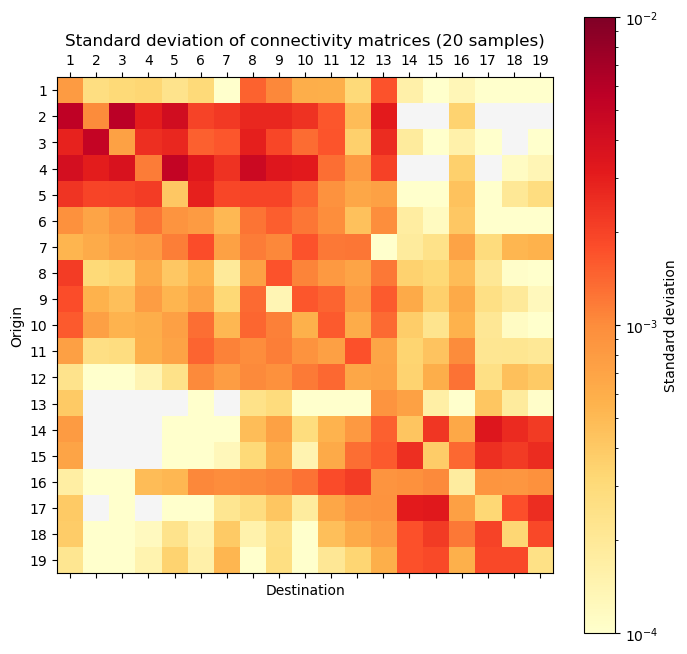

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
axis = np.arange(0, 19)

matrix_masked = np.ma.masked_where(std_matrix == 0, std_matrix) # mask exact zeros
norm = colors.LogNorm(1e-4, 1e-2)

im = ax.matshow(std_matrix, cmap='YlOrRd', norm=norm)
im.cmap.set_bad(color='whitesmoke')

# im = ax.matshow(std_matrix, cmap='YlOrRd')

plt.colorbar(im, ax=ax, label='Standard deviation')
plt.xticks(axis, farmIDs)
plt.yticks(axis, farmIDs)
ax.set_xlabel("Destination")
ax.set_ylabel("Origin")
ax.set_title(f'Standard deviation of connectivity matrices ({num_max} samples)')
plt.savefig(f"connectivity_matrices/Standard_deviation/Standard_deviation_N{num_max}.png")
plt.show()